In [189]:
# Import Library
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [33]:
# Create data sample
data = np.random.random((1000, 5, 4000)).astype(np.float32)
print(data.shape)

(1000, 5, 4000)


In [37]:
data_tensor = torch.from_numpy(data).float().unsqueeze(1)
print(data_tensor.shape)
print(data_tensor[0])

torch.Size([1000, 1, 5, 4000])
tensor([[[0.0374, 0.8154, 0.3568,  ..., 0.0505, 0.5697, 0.8043],
         [0.1013, 0.2107, 0.6107,  ..., 0.7099, 0.2981, 0.4643],
         [0.0928, 0.1920, 0.6792,  ..., 0.0433, 0.8597, 0.1172],
         [0.8013, 0.2207, 0.0185,  ..., 0.7958, 0.2818, 0.1205],
         [0.6894, 0.1454, 0.4991,  ..., 0.9146, 0.1178, 0.6225]]])


In [157]:
latent_dim = 64

conv2d_1 = nn.Conv2d(1, 16, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3))
conv2d_2 = nn.Conv2d(16, 32, kernel_size=(1, 10), stride = (1, 4), padding=(0,3))
conv2d_3 = nn.Conv2d(32, 64, kernel_size=(1, 10), stride = (1, 4), padding=(0,3))
conv2d_4 = nn.Conv2d(64, latent_dim, kernel_size=(1, 5), stride = (1, 2), padding=(0,2))

relu = nn.ReLU()

In [158]:
def print_info(x):
    print(x.shape)
    # print(x[0])

In [159]:
x = conv2d_1(data_tensor)
print_info(x)

torch.Size([1000, 16, 1, 1000])


In [160]:
x = relu(x)
x = conv2d_2(x)
print_info(x)

torch.Size([1000, 32, 1, 250])


In [161]:
x = relu(x)
x = conv2d_3(x)
print_info(x)

torch.Size([1000, 64, 1, 62])


In [162]:
x = relu(x)
x = conv2d_4(x)
print_info(x)

torch.Size([1000, 64, 1, 31])


In [178]:
# Reverse convolution
ct2d_1 = nn.ConvTranspose2d(latent_dim, 64, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2), output_padding=(0, 1))

In [179]:
xt = ct2d_1(x)
print_info(xt)

torch.Size([1000, 64, 1, 62])


In [180]:
ct2d_2 = nn.ConvTranspose2d(64, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 2))

In [181]:
xt = relu(xt)
xt = ct2d_2(xt)
print_info(xt)

torch.Size([1000, 32, 1, 250])


In [182]:
ct2d_3 = nn.ConvTranspose2d(32, 16, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 0))

In [183]:
xt = relu(xt)
xt = ct2d_3(xt)
print_info(xt)

torch.Size([1000, 16, 1, 1000])
tensor([[[-0.0381, -0.0388, -0.0414,  ..., -0.0359, -0.0407, -0.0361]],

        [[-0.0617, -0.0610, -0.0710,  ..., -0.0462, -0.0680, -0.0686]],

        [[ 0.0075, -0.0012,  0.0103,  ...,  0.0024,  0.0192, -0.0008]],

        ...,

        [[ 0.0215,  0.0182,  0.0229,  ...,  0.0203,  0.0257,  0.0309]],

        [[-0.0622, -0.0689, -0.0626,  ..., -0.0713, -0.0590, -0.0689]],

        [[ 0.0541,  0.0486,  0.0533,  ...,  0.0475,  0.0518,  0.0453]]],
       grad_fn=<SelectBackward0>)


In [185]:
ct2d_4 = nn.ConvTranspose2d(16, 1, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 0))

In [186]:
xt = relu(xt)
xt = ct2d_4(xt)
print_info(xt)

torch.Size([1000, 1, 5, 4000])


In [225]:
class CNNAutoEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(CNNAutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3)),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=(1, 10), stride = (1, 4), padding=(0,3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=(1, 10), stride = (1, 4), padding=(0,3)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, latent_dim, kernel_size=(1, 5), stride = (1, 2), padding=(0,2)),
            # nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2), output_padding=(0, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 2)),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 0)),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 0)),
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

In [226]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [227]:
# Split data to train and validation
X_train, X_val, y_train, y_val = train_test_split(data, data, test_size=0.2, random_state=1)

In [228]:
# Convert to Tensor
X_train_tensor = torch.from_numpy(X_train).float().unsqueeze(1).to(device)
X_val_tensor = torch.from_numpy(X_val).float().unsqueeze(1).to(device)

print_info(X_train_tensor)
print_info(X_val_tensor)

torch.Size([800, 1, 5, 4000])
torch.Size([200, 1, 5, 4000])


In [229]:
# Initialize the model
latent_dim = 64  # Size of the bottleneck layer
model = CNNAutoEncoder(latent_dim=latent_dim).to(device)
print(model)

CNNAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 64, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2), output_padding=(0, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(64, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(

In [230]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [231]:
# Training loop
n_epochs = 200
batch_size = 32
train_losses = []
val_losses = []

In [232]:
for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    
    # Train in batches
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_X)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, X_val_tensor)
    
    train_losses.append(train_loss / (len(X_train) / batch_size))
    val_losses.append(val_loss.item())
    
    # if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

Epoch [1/200], Train Loss: 0.0865, Val Loss: 0.0837
Epoch [2/200], Train Loss: 0.0835, Val Loss: 0.0834
Epoch [3/200], Train Loss: 0.0833, Val Loss: 0.0834
Epoch [4/200], Train Loss: 0.0832, Val Loss: 0.0832
Epoch [5/200], Train Loss: 0.0828, Val Loss: 0.0827
Epoch [6/200], Train Loss: 0.0821, Val Loss: 0.0819
Epoch [7/200], Train Loss: 0.0812, Val Loss: 0.0811
Epoch [8/200], Train Loss: 0.0805, Val Loss: 0.0805
Epoch [9/200], Train Loss: 0.0800, Val Loss: 0.0799
Epoch [10/200], Train Loss: 0.0795, Val Loss: 0.0795
Epoch [11/200], Train Loss: 0.0791, Val Loss: 0.0791
Epoch [12/200], Train Loss: 0.0788, Val Loss: 0.0788
Epoch [13/200], Train Loss: 0.0785, Val Loss: 0.0785
Epoch [14/200], Train Loss: 0.0783, Val Loss: 0.0784
Epoch [15/200], Train Loss: 0.0781, Val Loss: 0.0782
Epoch [16/200], Train Loss: 0.0779, Val Loss: 0.0780
Epoch [17/200], Train Loss: 0.0777, Val Loss: 0.0778
Epoch [18/200], Train Loss: 0.0776, Val Loss: 0.0777
Epoch [19/200], Train Loss: 0.0774, Val Loss: 0.0775
Ep

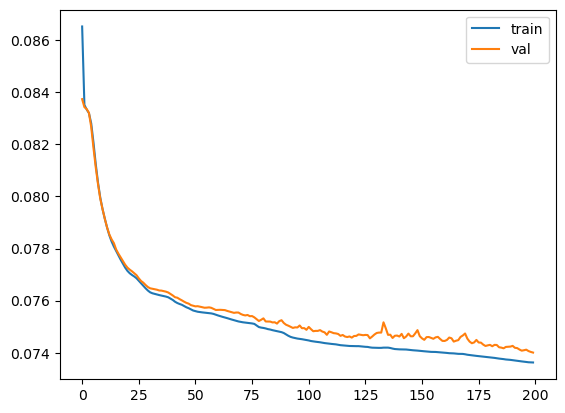

In [233]:
# Plot training results
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.show()

In [234]:
X_train_transformed = model.encode(X_train_tensor)

In [235]:
print_info(X_train_transformed)

torch.Size([800, 64, 1, 31])
